# *Whispers* **of** **the** **Machine** - Poem Generation Project

    "The poet's eye, in a fine frenzy rolling,
    Doth glance from heaven to earth, from earth to heaven;
    And as imagination bodies forth
    The forms of things unknown, the poet’s pen
    Turns them to shapes, and gives to airy nothing
    A local habitation and a name."

    — A Midsummer Night’s Dream, Act 5, Scene 1

This project transforms algorithms into poets, using words inspired by the masters—Shakespeare, Frost, and beyond. Each line is a fusion of logic and art, where code meets creativity. Can a machine capture the soul of verse? Let’s find out.

## Importing The Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import math
import tensorflow as tf
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
from sklearn.model_selection import train_test_split
from spacy.lang.en.stop_words import STOP_WORDS as stopwords
from sklearn.model_selection import GroupKFold
from keras.callbacks import EarlyStopping

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense,Flatten,Embedding,Dropout, LSTM, Embedding, BatchNormalization
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers


## Reading The Dataset

In [3]:
data = pd.read_csv('PoetryFoundationData.csv')
#data = data[:560] #tried with whole dataset, then it is too big, so took only first 520 poems
data = data[:300]
data.head(4)

,Unnamed: 0,Title,Poem,Poet,Tags
0,0,\r\r\n Objects Used to Prop...,"\r\r\nDog bone, stapler,\r\r\ncribbage board, ...",Michelle Menting,NaN
1,1,\r\r\n The New Church\r\r\n...,"\r\r\nThe old cupola glinted above the clouds,...",Lucia Cherciu,NaN
2,2,\r\r\n Look for Me\r\r\n ...,\r\r\nLook for me under the hood\r\r\nof that ...,Ted Kooser,NaN
3,3,\r\r\n Wild Life\r\r\n ...,"\r\r\nBehind the silo, the Mother Rabbit\r\r\n...",Grace Cavalieri,NaN


In [4]:
data.shape

(300, 5)

In [5]:
poem_data = pd.DataFrame({'Poem':data['Poem'].values})
poem_data.sample(4)  #dataset with only the poem columns

,Poem
40,"\r\r\nMad has decided to catch a vulture,\r\r\..."
293,\r\r\nwe aren't differentiable with bangs and ...
223,\r\r\nPerhaps you can tell children that the w...
148,\r\r\nShe cannot imagine it otherwise.\r\r\nSh...


## Removing Lines

In [6]:
poem_data['Poem'][0]

"\r\r\nDog bone, stapler,\r\r\ncribbage board, garlic press\r\r\n     because this window is loose—lacks\r\r\nsuction, lacks grip.\r\r\nBungee cord, bootstrap,\r\r\ndog leash, leather belt\r\r\n     because this window had sash cords.\r\r\nThey frayed. They broke.\r\r\nFeather duster, thatch of straw, empty\r\r\nbottle of Elmer's glue\r\r\n     because this window is loud—its hinges clack\r\r\nopen, clack shut.\r\r\nStuffed bear, baby blanket,\r\r\nsingle crib newel\r\r\n     because this window is split. It's dividing\r\r\nin two.\r\r\nVelvet moss, sagebrush,\r\r\nwillow branch, robin's wing\r\r\n     because this window, it's pane-less. It's only\r\r\na frame of air.\r\r\n"

In [7]:
poem_data['Poem'] = poem_data['Poem'].apply(lambda x: x.splitlines())

In [8]:
print(poem_data['Poem'][0])

['', '', 'Dog bone, stapler,', '', 'cribbage board, garlic press', '', '     because this window is loose—lacks', '', 'suction, lacks grip.', '', 'Bungee cord, bootstrap,', '', 'dog leash, leather belt', '', '     because this window had sash cords.', '', 'They frayed. They broke.', '', 'Feather duster, thatch of straw, empty', '', "bottle of Elmer's glue", '', '     because this window is loud—its hinges clack', '', 'open, clack shut.', '', 'Stuffed bear, baby blanket,', '', 'single crib newel', '', "     because this window is split. It's dividing", '', 'in two.', '', 'Velvet moss, sagebrush,', '', "willow branch, robin's wing", '', "     because this window, it's pane-less. It's only", '', 'a frame of air.', '']


In [9]:
poem_data['Poem'] = poem_data['Poem'].apply(lambda x: " ".join(x)) #we clean the poems

In [10]:
poem_data['Poem'][0]

"  Dog bone, stapler,  cribbage board, garlic press       because this window is loose—lacks  suction, lacks grip.  Bungee cord, bootstrap,  dog leash, leather belt       because this window had sash cords.  They frayed. They broke.  Feather duster, thatch of straw, empty  bottle of Elmer's glue       because this window is loud—its hinges clack  open, clack shut.  Stuffed bear, baby blanket,  single crib newel       because this window is split. It's dividing  in two.  Velvet moss, sagebrush,  willow branch, robin's wing       because this window, it's pane-less. It's only  a frame of air. "

## Cleaning The Text

In [11]:
!pip -q install contractions
import contractions
import unicodedata

In [12]:
def remove_accented(x): #we remove the unnecessary characters and symbols
  x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8', 'ignore')
  return x  #and put everything in lowercase

In [13]:
def get_clean(X):
    X = str(X).lower().replace('\\', ' ').replace('_', ' ').replace(':', '')
    X = contractions.fix(X)
    X = X.replace('#', "")
    X = re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?',"",  X)
    X = re.sub(r'[^\w\d\s]+','', X)
    X = ' '.join(X.split())
    X = BeautifulSoup(X, 'lxml').get_text().strip()
    X = remove_accented(X)
    return X

In [14]:
pip install lxml

Note: you may need to restart the kernel to use updated packages.


In [15]:
poem_data['Poem'] = poem_data['Poem'].apply(lambda x: get_clean(x))
poem_data['Poem'][0]

'dog bone stapler cribbage board garlic press because this window is looselacks suction lacks grip bungee cord bootstrap dog leash leather belt because this window had sash cords they frayed they broke feather duster thatch of straw empty bottle of elmers glue because this window is loudits hinges clack open clack shut stuffed bear baby blanket single crib newel because this window is split it is dividing in two velvet moss sagebrush willow branch robins wing because this window it is paneless it is only a frame of air'

## Word Cloud Representation


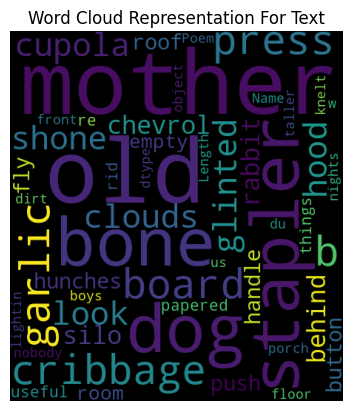

In [16]:
poems = str(poem_data['Poem'])
word_cloud = WordCloud(width=450, height=500, max_font_size=120).generate(poems)
plt.imshow(word_cloud)
plt.title('Word Cloud Representation For Text')
plt.axis('off')
plt.show()

## Converting Text Into Numerical Form

In [17]:
token = Tokenizer() #assign a number\token to each word
token.fit_on_texts(poem_data['Poem'])

In [18]:
token.word_index

{'the': 1,
 'a': 2,
 'of': 3,
 'and': 4,
 'to': 5,
 'i': 6,
 'in': 7,
 'is': 8,
 'you': 9,
 'it': 10,
 'my': 11,
 'not': 12,
 'on': 13,
 'that': 14,
 'with': 15,
 'for': 16,
 'as': 17,
 'we': 18,
 'was': 19,
 'he': 20,
 'his': 21,
 'like': 22,
 'your': 23,
 'at': 24,
 'her': 25,
 'but': 26,
 'me': 27,
 'this': 28,
 'from': 29,
 'be': 30,
 'will': 31,
 'are': 32,
 'or': 33,
 'when': 34,
 'all': 35,
 'one': 36,
 'they': 37,
 'have': 38,
 'she': 39,
 'what': 40,
 'their': 41,
 'by': 42,
 'into': 43,
 'if': 44,
 'our': 45,
 'no': 46,
 'who': 47,
 'an': 48,
 'would': 49,
 'up': 50,
 'so': 51,
 'there': 52,
 'do': 53,
 'out': 54,
 'us': 55,
 'its': 56,
 'am': 57,
 'can': 58,
 'back': 59,
 'how': 60,
 'them': 61,
 'could': 62,
 'were': 63,
 'had': 64,
 'has': 65,
 'where': 66,
 'then': 67,
 'through': 68,
 'black': 69,
 'down': 70,
 'him': 71,
 'over': 72,
 'man': 73,
 'love': 74,
 'now': 75,
 'let': 76,
 'know': 77,
 'too': 78,
 'see': 79,
 'after': 80,
 'light': 81,
 'time': 82,
 'said': 83

In [19]:
encoded_text = token.texts_to_sequences(poem_data['Poem'])

In [20]:
encoded_text[0] # encoded first poem

[366,
 1178,
 4126,
 4127,
 1426,
 2546,
 1179,
 98,
 28,
 266,
 8,
 4128,
 4129,
 2547,
 1180,
 4130,
 1427,
 4131,
 366,
 4132,
 2548,
 1428,
 98,
 28,
 266,
 64,
 4133,
 4134,
 37,
 1429,
 37,
 367,
 1843,
 4135,
 4136,
 3,
 1844,
 348,
 2549,
 3,
 4137,
 2550,
 98,
 28,
 266,
 8,
 4138,
 4139,
 2551,
 178,
 2551,
 1016,
 1845,
 598,
 653,
 1017,
 550,
 4140,
 4141,
 98,
 28,
 266,
 8,
 599,
 10,
 8,
 4142,
 7,
 111,
 2552,
 4143,
 4144,
 4145,
 712,
 4146,
 786,
 98,
 28,
 266,
 10,
 8,
 4147,
 10,
 8,
 87,
 2,
 1846,
 3,
 125]

In [21]:
vocab_size = len(token.word_counts) + 1  
print(f'Vocab Size: {vocab_size}')

Vocab Size: 10496


## Building The Data

In [22]:
datalist = []
for d in encoded_text:
  if len(d)>1:
    for i in range(2, len(d)):
      datalist.append(d[:i])

In [23]:
#make all possible m-grams

In [24]:
datalist[:10]

[[366, 1178],
 [366, 1178, 4126],
 [366, 1178, 4126, 4127],
 [366, 1178, 4126, 4127, 1426],
 [366, 1178, 4126, 4127, 1426, 2546],
 [366, 1178, 4126, 4127, 1426, 2546, 1179],
 [366, 1178, 4126, 4127, 1426, 2546, 1179, 98],
 [366, 1178, 4126, 4127, 1426, 2546, 1179, 98, 28],
 [366, 1178, 4126, 4127, 1426, 2546, 1179, 98, 28, 266],
 [366, 1178, 4126, 4127, 1426, 2546, 1179, 98, 28, 266, 8]]

In [25]:
#the input layer requires input in same length, so need to add padding

In [26]:
max_length = 5
sequences = pad_sequences(datalist, maxlen=max_length, padding='pre')

In [27]:
sequences[:10]

array([[   0,    0,    0,  366, 1178],
       [   0,    0,  366, 1178, 4126],
       [   0,  366, 1178, 4126, 4127],
       [ 366, 1178, 4126, 4127, 1426],
       [1178, 4126, 4127, 1426, 2546],
       [4126, 4127, 1426, 2546, 1179],
       [4127, 1426, 2546, 1179,   98],
       [1426, 2546, 1179,   98,   28],
       [2546, 1179,   98,   28,  266],
       [1179,   98,   28,  266,    8]])

In [28]:
seq_length = sequences.shape[1]
print(f'Sequence Length: {seq_length}')

Sequence Length: 5


## Dividing The Data

In [29]:
X = sequences[:, :-1]
y = sequences[:, -1]

In [30]:
X.shape #in these sequences, first four words are input

(62183, 4)

In [31]:
y.shape #last word is the output, because we need to predict the next word

(62183,)

In [32]:
y = to_categorical(y, num_classes=vocab_size) #one hot encoding

In [33]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Building The Model

In [34]:
model = Sequential()
model.add(Embedding(vocab_size, 50))
model.build(input_shape=(None, seq_length))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(50, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(vocab_size, activation='softmax'))


## Understanding The Model

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 50)          │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10496)          │       535,296 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,246 (4.21 MB)

 Trainable params: 1,103,146 (4.21 MB)

 Non-trainable params: 100 (400.00 B)

In [36]:
plot_model(model, show_shapes=True, show_layer_names=True, dpi=80)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## Compiling The Model

In [ ]:
model.compile(loss='categorical_crossentrophy', optimizer='adam', metrics=['accuracy'])

## Training The Model

In [ ]:
r = model.fit(X, y, batch_size=100, epochs=300)

Epoch 1/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.0687 - loss: 7.3999
Epoch 2/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.0893 - loss: 6.4923
Epoch 3/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.1106 - loss: 6.1480
Epoch 4/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1304 - loss: 5.8372
Epoch 5/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1485 - loss: 5.5327
Epoch 6/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1660 - loss: 5.2256
Epoch 7/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1867 - loss: 4.9216
Epoch 8/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2124 - loss: 4.6150
Epoch 9/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2392 - loss: 4.3123
Epoch 10/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2767 - loss: 4.0053
Epoch 11/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3210 - loss: 3.7056
Epoch 12/170
622/622 ━━━━

## Accuracy and Loss
print(f'The traning accuracy of model is {math.floor(r.history["accuracy"][-1] * 100)} %')
print(f'The traning loss of model is {r.history["loss"][-1]:.3f}')

In [ ]:
print(f'The traning accuracy of model is {math.floor(r.history["accuracy"][-1] * 100)} %')
print(f'The traning loss of model is {r.history["loss"][-1]:.3f}')

The traning accuracy of model is 93 %
The traning loss of model is 0.236


In [ ]:
# loss_LSTM, accuracy_LSTM = model.evaluate(X, y)
# print(f"Test Loss: {loss_LSTM}, Test Accuracy: {loss_LSTM}")

In [ ]:
plt.rcParams['figure.figsize'] = [22,6]
plt.rcParams['figure.dpi'] = 75

## Visualizing The Accuracy

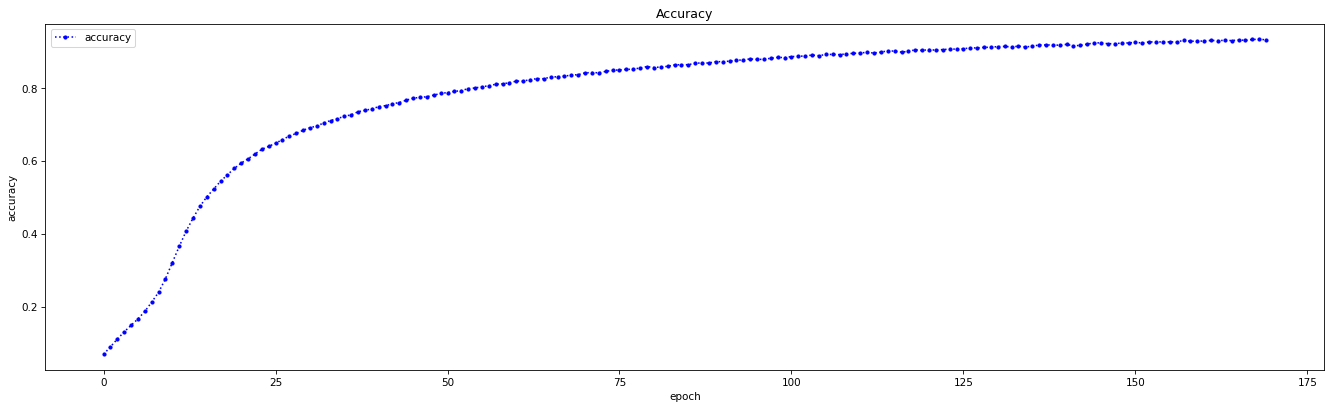

In [ ]:
plt.title('Accuracy')
plt.plot(r.history['accuracy'], ".:", label='accuracy', linewidth=1.5, color="blue")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Visualizing The Loss

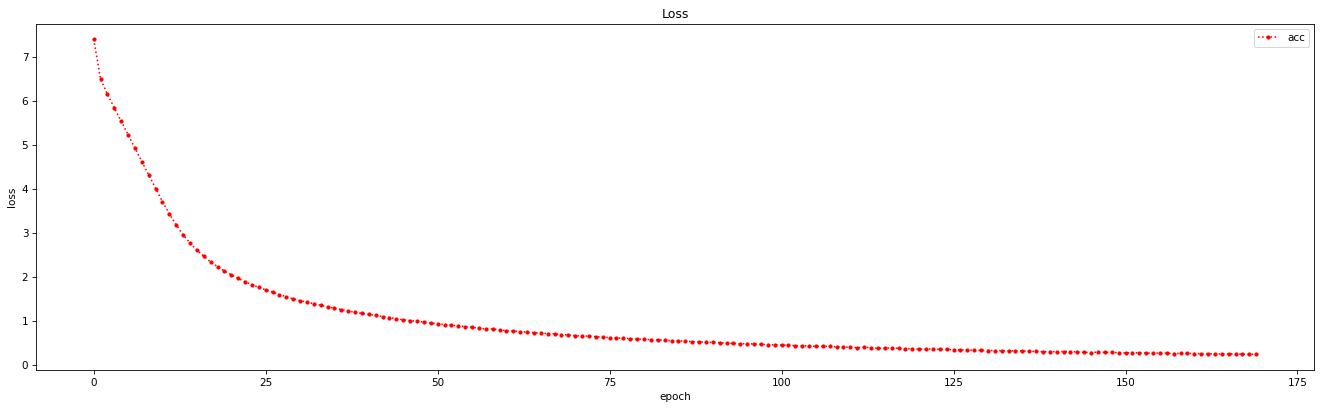

In [ ]:
plt.title('Loss')
plt.plot(r.history['loss'], ".:", label='acc', linewidth=1.5, color="red")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

# **PPL**

In [ ]:
loss, accuracy = model.evaluate(X, y)  # Evaluate on the same training data

# Step 3: Calculate perplexity using the loss
perplexity = np.exp(loss)
print(f"Perplexity on training data: {perplexity}")

1944/1944 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9628 - loss: 0.1419
Perplexity on training data: 1.1524473010844625


# **K-Fold cross validation**

In [45]:
from sklearn.model_selection import KFold

num_folds = 5
kf = KFold(n_splits=num_folds)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

fold_no = 1
for train_idx, val_idx in kf.split(X):
    print(f"Training on fold {fold_no}...")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=50))
    model.build(input_shape=(None, seq_length))
    model.add(LSTM(30, return_sequences=True))
    model.add(LSTM(30))
    model.add(Dense(50, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(vocab_size, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=1)

    train_losses.append(history.history['loss'][-1])
    val_losses.append(history.history['val_loss'][-1])
    train_accuracies.append(history.history['accuracy'][-1])
    val_accuracies.append(history.history['val_accuracy'][-1])

    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold_no}: Loss = {loss}, Accuracy = {accuracy}")

    fold_no += 1

avg_train_loss = np.mean(train_losses)
avg_val_loss = np.mean(val_losses)
avg_train_accuracy = np.mean(train_accuracies)
avg_val_accuracy = np.mean(val_accuracies)

print(f"Average Train Loss: {avg_train_loss}")
print(f"Average Validation Loss: {avg_val_loss}")
print(f"Average Train Accuracy: {avg_train_accuracy}")
print(f"Average Validation Accuracy: {avg_val_accuracy}")


Training on fold 1...
Epoch 1/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.0683 - loss: 7.2216 - val_accuracy: 0.0873 - val_loss: 6.9417
Epoch 2/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.0902 - loss: 6.4713 - val_accuracy: 0.0952 - val_loss: 7.1821
Epoch 3/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.1114 - loss: 6.1240 - val_accuracy: 0.0908 - val_loss: 7.0785
Epoch 4/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.1280 - loss: 5.8309 - val_accuracy: 0.0857 - val_loss: 7.2675
Epoch 5/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.1447 - loss: 5.5460 - val_accuracy: 0.0773 - val_loss: 7.7142
Epoch 6/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.1614 - loss: 5.2569 - val_accuracy: 0.0830 - val_loss: 7.7464
Epoch 7/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.1803 - loss: 4.9666 - val_accuracy: 0.0757 - val_loss: 8.6301
Epoch 8/10
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/ste

## Generating The Poems




In [46]:
poetry_length = 10

def generate_poetry(seed_text, n_lines):

  for i in range(n_lines):
    text = []
    for _ in range(poetry_length):
      encoded = token.texts_to_sequences([seed_text])
      encoded = pad_sequences(encoded, maxlen=seq_length, padding='pre')

      y_pred = np.argmax(model.predict(encoded, verbose=0), axis=-1)

      predicted_word = ""
      for word, index in token.word_index.items(): #search the predicted word's index
        if index == y_pred:
          predicted_word = word
          break

      seed_text = seed_text + ' ' + predicted_word
      text.append(predicted_word)

    seed_text = text[-1]
    text = ' '.join(text)
    print(text)

## Result

In [47]:
seed_text = 'Kiss'
print(f'Title: {seed_text}')
generate_poetry(seed_text, 5)

Title: Kiss
the earth where the end of the moon the night
the day where the birds has still my father is
the night of the moon the dead is the night
the day where the birds has still my father is
the night of the moon the dead is the night


In [48]:
seed_text = 'Once upon a time'
print(f'Title: {seed_text}')
generate_poetry(seed_text, 5)

Title: Once upon a time
the word i have have still the last night the
day where the birds has still my father is the
day where the birds has still my father is the
day where the birds has still my father is the
day where the birds has still my father is the


In [49]:
seed_text = 'Beauty'
print(f'Title: {seed_text}')
generate_poetry(seed_text, 5)

Title: Beauty
of the edge of the night the word is the
day where the birds has still my father is the
day where the birds has still my father is the
day where the birds has still my father is the
day where the birds has still my father is the


In [50]:
model.save('Poem_Writing_AI.h5')

In [51]:
#next check for other models for poem generation and translation

# **RNN**

In [52]:
model_RNN = Sequential([
    Embedding(input_dim=vocab_size, output_dim=50, input_length=seq_length),
    SimpleRNN(100, return_sequences=False),
    Dense(vocab_size, activation='softmax')
    # predict probabilities for each word in vocab
])

# Build the model explicitly
model_RNN.build(input_shape=(None, seq_length))


c:\Users\aless\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [53]:
model_RNN.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 5, 50)          │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10496)          │     1,060,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,599,996 (6.10 MB)

 Trainable params: 1,599,996 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Compile the model
model_RNN.compile(
    loss='categorical_crossentropy',  # because y is one-hot encoded
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
#model_RNN.fit(X, y, epochs=170, batch_size=100, validation_split=0.2)
model_RNN.fit(X, y, epochs=170, batch_size=100)

Epoch 1/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.0659 - loss: 7.2948
Epoch 2/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.0755 - loss: 6.6921
Epoch 3/170
495/622 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0854 - loss: 6.2917

In [ ]:
model_RNN.fit(X, y, epochs=100, batch_size=50)

Epoch 1/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0640 - loss: 7.5214
Epoch 2/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0761 - loss: 6.6449
Epoch 3/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 6.1279
Epoch 4/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1170 - loss: 5.6198
Epoch 5/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1419 - loss: 5.1832
Epoch 6/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1783 - loss: 4.7700
Epoch 7/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2290 - loss: 4.3759
Epoch 8/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2795 - loss: 4.0265
Epoch 9/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3376 - loss: 3.6781
Epoch 10/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3819 - loss: 3.3795
Epoch 11/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4339 - loss: 3.0813
Epoch 12/100
124

In [ ]:
loss, accuracy = model_RNN.evaluate(X, y)
#print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

1944/1944 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9684 - loss: 0.1286


In [ ]:
model_RNN.save('Poem_Writing_AI_RNN.h5')

In [ ]:
#model = load_model('/content/Poem_Writing_AI.h5')

In [ ]:
perplexity = np.exp(loss)
print(f"Perplexity on training data: {perplexity}")

Perplexity on training data: 1.1336798375438537


In [ ]:
def generate_text(seed_text, model, tokenizer, max_length=50, line_length=7):
    poem = seed_text
    word_count = len(seed_text.split())

    for _ in range(max_length):
        tokenized = tokenizer.texts_to_sequences([seed_text])[0]

        if len(tokenized) > X.shape[1]:
            tokenized = tokenized[-X.shape[1]:]

        tokenized = np.pad(tokenized, (X.shape[1] - len(tokenized), 0), mode='constant')

        predictions = model.predict(tokenized[np.newaxis, :], verbose=0)
        next_token = np.argmax(predictions, axis=-1)[0]

        next_word = tokenizer.index_word[next_token]
        seed_text += " " + next_word
        poem += " " + next_word
        word_count += 1

        if word_count % line_length == 0:
            poem += "\n"

        if next_word == '<eos>':
            break

    return poem

In [ ]:
seed = "love"
print(f"{seed}")
generated_poem = generate_text(seed, model_RNN, token)
print(generated_poem)

love
love in the halakhas an thousand day
 of river happiness burning while my side
 so is everything to the brink of
 insanity let them all sleep and dream
 that the god of war has brought
 them riches in the shape of gold
 nuggets only to find in the morning
 an empty


In [ ]:
#looks performing well, but overfitting

In [ ]:
from keras.layers import Embedding, SimpleRNN, Dense, Dropout
from keras.regularizers import l2

# Define the RNN model with regularization and dropout
model_RNN_ = Sequential([
    Embedding(input_dim=vocab_size, output_dim=50, input_length=X.shape[1]),
    SimpleRNN(128, dropout=0.1, recurrent_dropout=0.1),
    Dense(vocab_size, activation='softmax', kernel_regularizer=l2(0.001))
])

model_RNN_.build(input_shape=(None, X.shape[1]))

model_RNN_.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_RNN_.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 4, 50)               │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 100)                 │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10496)               │       1,060,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,599,996 (6.10 MB)

 Trainable params: 1,599,996 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_RNN_.fit(X, y, epochs=170, batch_size=100, validation_split=0.2)

Epoch 1/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.0589 - loss: 8.1346 - val_accuracy: 0.0585 - val_loss: 7.4374
Epoch 2/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0645 - loss: 7.3950 - val_accuracy: 0.0585 - val_loss: 7.4594
Epoch 3/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0641 - loss: 7.3696 - val_accuracy: 0.0584 - val_loss: 7.4769
Epoch 4/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0640 - loss: 7.3484 - val_accuracy: 0.0585 - val_loss: 7.4793
Epoch 5/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0648 - loss: 7.2975 - val_accuracy: 0.0584 - val_loss: 7.4265
Epoch 6/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0645 - loss: 7.1972 - val_accuracy: 0.0584 - val_loss: 7.4417
Epoch 7/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0664 - loss: 7.1315 - val_accuracy: 0.0594 - val_loss: 7.4750
Epoch 8/170
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0732 - loss: 7.0888 - val_ac

In [ ]:
loss_, accuracy_ = model_RNN_.evaluate(X, y)
print(f"Test Loss: {loss_}, Test Accuracy: {accuracy_}")

In [ ]:
#not overfitting, but need to train more since accuracy is law and loss is high

# **GRU**

In [ ]:
from tensorflow.keras.layers import GRU, Dense, Embedding

model_GRU = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100),
    GRU(50, return_sequences=False),
    Dense(vocab_size, activation='softmax')
])

model_GRU.build(input_shape=(None, X.shape[1]))

In [ ]:
model_GRU.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 4, 100)              │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 50)                  │          22,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10496)               │         535,296 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,607,696 (6.13 MB)

 Trainable params: 1,607,696 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_GRU.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_GRU.fit(X, y , epochs=170, batch_size=100)

Epoch 1/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.0608 - loss: 7.7721
Epoch 2/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0627 - loss: 6.8487
Epoch 3/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.0751 - loss: 6.6054
Epoch 4/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.0904 - loss: 6.3596
Epoch 5/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.1015 - loss: 6.1507
Epoch 6/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1110 - loss: 5.9681
Epoch 7/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1197 - loss: 5.7499
Epoch 8/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1288 - loss: 5.5633
Epoch 9/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1404 - loss: 5.3610
Epoch 10/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1532 - loss: 5.1720
Epoch 11/170
622/622 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1657 - loss: 5.0170
Epoch 12/170
622/622 ━━━━━

In [ ]:
model_GRU.fit(X, y , epochs=100, batch_size=50)

Epoch 1/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.0632 - loss: 7.5914
Epoch 2/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.0757 - loss: 6.7098
Epoch 3/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.0889 - loss: 6.3869
Epoch 4/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1085 - loss: 6.0625
Epoch 5/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1209 - loss: 5.7857
Epoch 6/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1341 - loss: 5.5092
Epoch 7/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.1470 - loss: 5.2625
Epoch 8/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1677 - loss: 4.9949
Epoch 9/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1944 - loss: 4.7123
Epoch 10/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2190 - loss: 4.4864
Epoch 11/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2521 - loss: 4.2569
Epoch 12/100


In [ ]:
model_GRU.fit(X, y , epochs=100, batch_size=50, validation_split=0.2)

Epoch 1/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.0618 - loss: 7.6785 - val_accuracy: 0.0585 - val_loss: 7.1690
Epoch 2/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.0638 - loss: 6.7966 - val_accuracy: 0.0671 - val_loss: 7.1878
Epoch 3/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.0758 - loss: 6.5188 - val_accuracy: 0.0770 - val_loss: 7.2239
Epoch 4/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.0944 - loss: 6.2387 - val_accuracy: 0.0876 - val_loss: 7.2524
Epoch 5/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.1148 - loss: 5.9280 - val_accuracy: 0.0901 - val_loss: 7.4091
Epoch 6/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.1220 - loss: 5.6502 - val_accuracy: 0.0909 - val_loss: 7.5366
Epoch 7/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.1373 - loss: 5.3738 - val_accuracy: 0.0902 - val_loss: 7.6663
Epoch 8/100
995/995 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.1538 - loss: 5

KeyboardInterrupt: 

In [ ]:
model_GRU.save('Poem_Writing_AI_GRU.h5')

In [ ]:
loss, accuracy = model_GRU.evaluate(X, y)
#print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

1944/1944 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9077 - loss: 0.4350


In [ ]:
#model = load_model('/content/Poem_Writing_AI.h5')

In [ ]:
perplexity = np.exp(loss)
print(f"Perplexity on training data: {perplexity}")

Perplexity on training data: 1.5376405401756716


In [ ]:
def generate_poem_GRU(seed_text, model, tokenizer, max_length=50, temperature=1.0):

    generated_text = seed_text

    for _ in range(max_length):
        tokenized = tokenizer.texts_to_sequences([seed_text])[0]

        if len(tokenized) > model_GRU.input_shape[1]:
            tokenized = tokenized[-model_GRU.input_shape[1]:]

        tokenized = np.pad(tokenized, (model_GRU.input_shape[1] - len(tokenized), 0), mode='constant')

        # Predict the next word probabilities
        predictions = model.predict(tokenized[np.newaxis, :], verbose=0)[0]

        # Apply temperature to control randomness
        predictions = np.log(predictions + 1e-10) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))

        # Sample the next word's token
        next_token = np.random.choice(range(len(predictions)), p=predictions)

        # Map the token back to a word
        next_word = tokenizer.index_word.get(next_token, "<unk>")

        # Stop if end-of-sequence token is generated
        if next_word == '<eos>':
            break

        # Add the word to the generated text
        seed_text += " " + next_word
        generated_text += " " + next_word

        # Break the line for better readability (every 7 words)
        if len(generated_text.split()) % 7 == 0:
            generated_text += "\n"

    return generated_text


In [ ]:
loss_GRU, accuracy_GRU = model_GRU.evaluate(X, y)
# print(f"Test Loss: {loss_GRU}, Test Accuracy: {accuracy_GRU}")

1944/1944 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8966 - loss: 0.4810


In [ ]:
seed = "love"
print(f"{seed}")
generated_poem_ = generate_poem_GRU(seed, model_GRU, token)
print(generated_poem_)

love
love should roll up they poor her
 too children to break which if you
 were mine for a car new she
 made it and alone and through a
 hard why keep all i sit on
 a clipper blood and still glimpse all
 of this man who gave me as
 you will


In [ ]:
seed = "Once upon a"
print(f"{seed}")
generated_poem_ = generate_poem_GRU(seed, model_GRU, token)
print(generated_poem_)

Once upon a
Once upon a more than pink high
 times which i appropriate be such a
 single color imaginary devil and imaginary son
 the time not to be and through
 the word straight and the attention in
 a busted speaker suppose you had to
 wipe sweat from the brow of a
 righteous body to would


In [ ]:
seed = "Flowers bloom"
print(f"{seed}")
generated_poem_ = generate_poem_GRU(seed, model_GRU, token)
print(generated_poem_)

Flowers bloom
Flowers bloom of border wall peri of
 love but they saw her back from
 every plow soon as my child why
 is around of course moses summer like
 snow and sleeping a friend like without
 many too place many rude comfort by
 her your bank whatever boy the god
 is so small


# **Analysis**

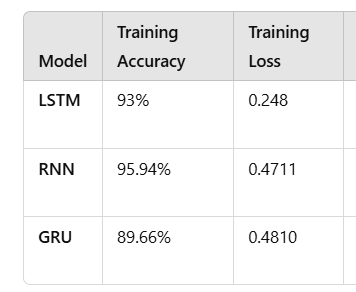

***Generated Text Quality:***

**LSTM:** Produces more structured text with slightly better grammar but struggles with meaning and coherence/logical flow.

**RNN:**Slightly better text structure than LSTM but fails to maintain semantic meaning or logical flow.

**GRU:** Generates text with little logical structure, struggling the most with grammar and coherence.


***Based on the results:***

LSTM appears to be the best for this, as it has the lowest loss and produces relatively coherent text compared to the others. Its architecture allows it to handle longer dependencies better than RNNs and GRUs.

RNN performs decently but seems to struggle with overfitting. It also lacks the capacity to capture long-term dependencies, making it less suitable for creative text generation.

NOTE: Due to the memory issue, only 300 poems were considered.